In [26]:
import pandas as pd

df = pd.read_csv('C:\\Users\\Lenovo\\Desktop\\coliz DA\\beeskilled\\week4\\capstone_cleaned.csv')

KPIs

In [27]:
total_sales = df['Sales'].sum().round(2)
total_profit = df['Profit'].sum().round(2)
total_units_sold = df['Units Sold'].sum()

EDA

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

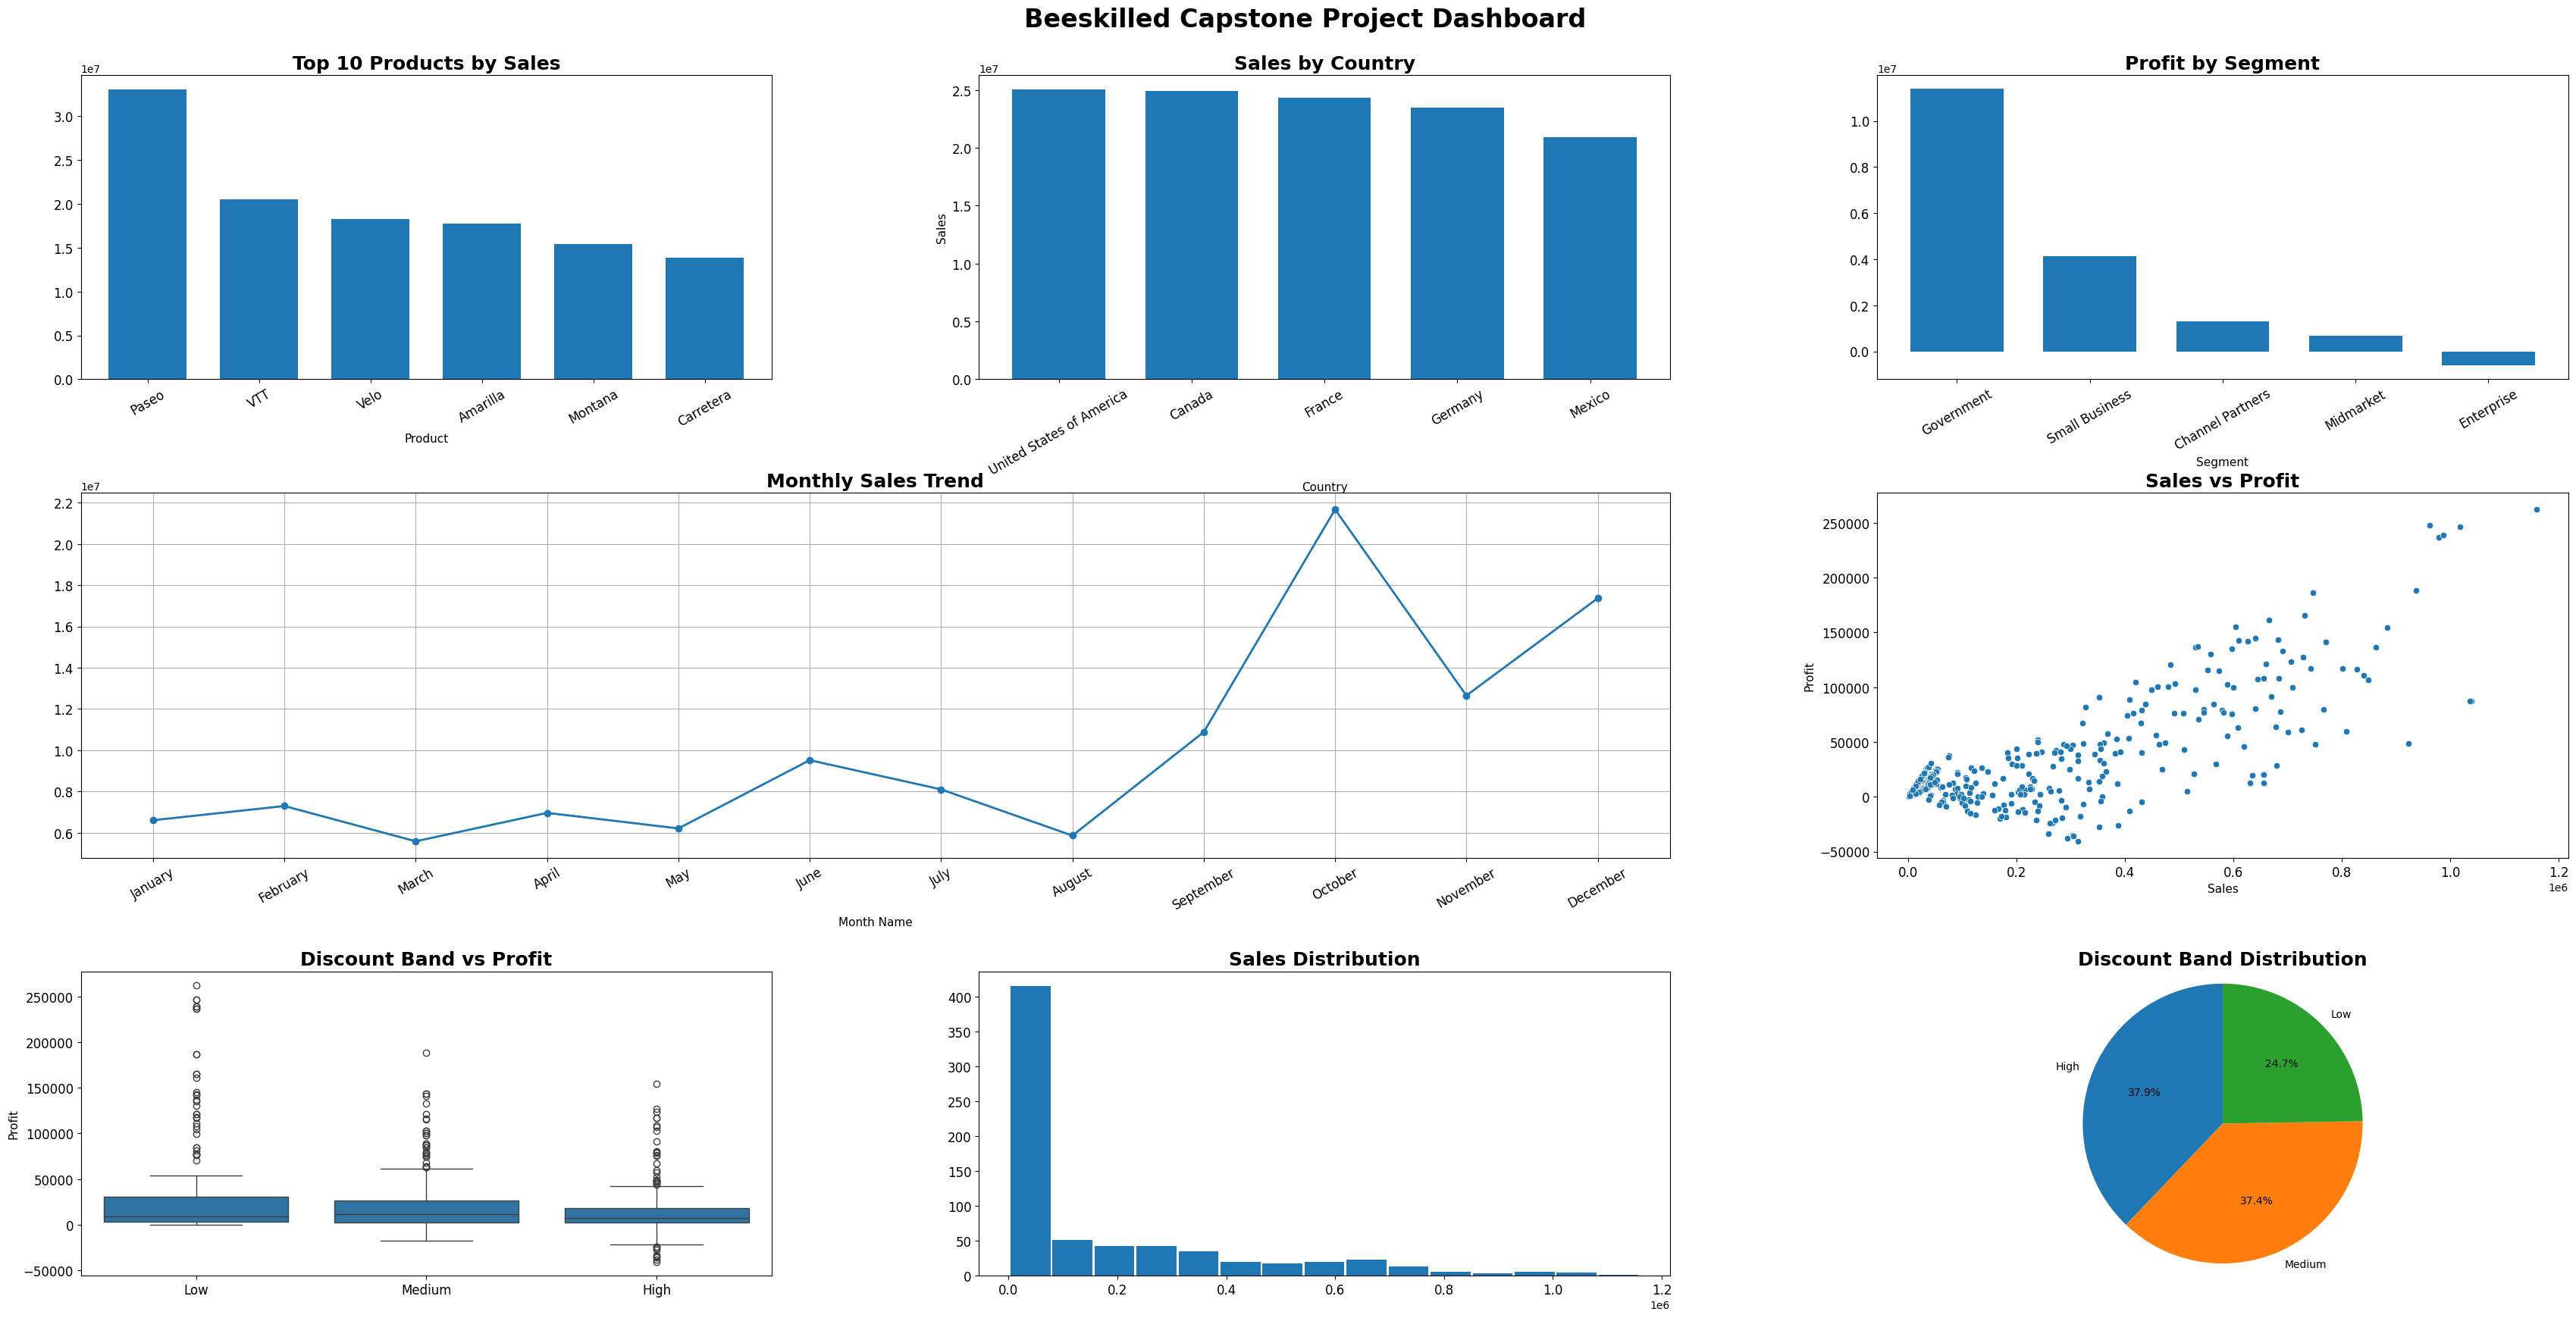

In [29]:
fig = plt.figure(figsize=(34, 18))
gs = GridSpec(3,3, figure=fig,
    height_ratios=[1.5, 1.8, 1.5]
)

fig.suptitle(
    "Beeskilled Capstone Project Dashboard",
    fontsize=24,
    fontweight="bold"
)

# Layout
ax1 = fig.add_subplot(gs[0, 0])      # Product
ax2 = fig.add_subplot(gs[0, 1])      # Country
ax3 = fig.add_subplot(gs[0, 2])      # Segment

ax4 = fig.add_subplot(gs[1, 0:2])    # Monthly Sales (spans 2 columns)
ax5 = fig.add_subplot(gs[1, 2])      # Scatter

ax6 = fig.add_subplot(gs[2, 0])      # Boxplot
ax7 = fig.add_subplot(gs[2, 1])      # Histogram
ax8 = fig.add_subplot(gs[2, 2])      # Pie


#1. Product Sales
product_sales = df.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(10)
product_sales.plot(kind='bar', ax=ax1, width = 0.7)
ax1.set_title('Top 10 Products by Sales')


#2. Country Sales
country_sales = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)
country_sales.plot(kind='bar', ax=ax2, width = 0.7)
ax2.set_title('Sales by Country')
ax2.set_ylabel('Sales')


#3. Segment Profit
segment_profit = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)
segment_profit.plot(kind='bar', ax=ax3, width = 0.7)
ax3.set_title('Profit by Segment')


# 4.Monthly Sales Trend
'''
monthly_sales = df.groupby(['Month Name', 'Month Number'])['Sales'].sum().sort_values(by = 'Month Number')
after grp by and sum, monthly sales becomes a series
sort_values(by = 'Month Number') will not work on series, it works on dataframe only

so we used
as_index=False: it does not set the group keys as index, so the result is a dataframe
now we can use sort_values(by='Month Number') or sort_values('Month Number')
'''

monthly_sales = (
    df.groupby(['Month Name', 'Month Number'], as_index=False)['Sales']
      .sum()
      .sort_values('Month Number')
)

monthly_sales.plot(
    x='Month Name',
    y='Sales',
    kind='line',
    marker='o',
    linewidth=2,
    ax=ax4
)

'''
Force all month names to appear
'''

ax4.set_xticks(range(len(monthly_sales)))
ax4.set_xticklabels(monthly_sales['Month Name'], rotation=30)
ax4.set_title('Monthly Sales Trend')
ax4.grid(True)
ax4.get_legend().remove()


# 5. Sales vs Profit
sns.scatterplot(
    data=df,
    x='Sales',
    y='Profit',
    ax=ax5
)
ax5.set_title('Sales vs Profit')


#6. Discount Band vs Profit
sns.boxplot(
    data=df,
    x='Discount Band',
    y='Profit',
    ax=ax6
)

ax6.set_title('Discount Band vs Profit')
ax6.set_xlabel("")      # Remove x-axis label
ax6.tick_params(axis='x', rotation=0)


#7. Sales Distribution
ax7.hist(df['Sales'], bins=15, rwidth=0.95)
ax7.set_title('Sales Distribution')


#8. Discount Band Distribution
discount_band_counts = df['Discount Band'].value_counts()

discount_band_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    radius=1.15,
    ax=ax8
)

ax8.set_title('Discount Band Distribution')
ax8.set_ylabel("")


# -----------------------------
# Common formatting
# -----------------------------

for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]:

    ax.title.set_fontsize(18)
    ax.title.set_fontweight('bold')

    ax.xaxis.label.set_size(11)
    ax.yaxis.label.set_size(11)

    ax.tick_params(
        axis='both',
        labelsize=12
    )

# Long category names
ax1.tick_params(axis='x', rotation=30)
ax2.tick_params(axis='x', rotation=30)
ax3.tick_params(axis='x', rotation=30)
ax4.tick_params(axis='x', rotation=30)

# More breathing room
plt.subplots_adjust(
    left=0.025,
    right=0.99,
    top=0.93,
    bottom=0.05,
    hspace=0.35,
    wspace=0.30
)

plt.show()

Business Insights

In [ ]:
print(f"- Total Sales reached {total_sales}, generating a total profit of {total_profit}.")
print(f"- The {segment_profit.index[0]} segment contributes the highest sales/profit.")
print(f"- {country_sales.index[0]} generated the highest revenue.")
print(f"- {total_units_sold} units were sold in total this period.")
print(f"- {product_sales.index[0]} became the best selling product with a total sales of {product_sales.iloc[0]}.")
print(f"- The month of {monthly_sales.iloc[monthly_sales['Sales'].idxmax()]['Month Name']} generated the highest sales of {monthly_sales['Sales'].max()}.")
print(f"- {discount_band_counts.idxmax()} discount band had the highest number of orders, accounting for {discount_band_counts.max()} orders.")
print("- Higher discount bands tend to have lower profits, as seen in the boxplot.")
print("- Strong positive correlation between sales and profit, as seen in the scatter plot.")


- Total Sales reached 118726350.26, generating a total profit of 16893702.26.
- The Government segment contributes the highest sales/profit.
- United States of America generated the highest revenue.
- 1125806.0 units were sold in total this period.
- Paseo became the best selling product with a total sales of 33011143.95.
- The month of November generated the highest sales of 21671431.02.
- High discount band had the highest number of orders, accounting for 245 orders.
- Higher discount bands tend to have lower profits, as seen in the boxplot.
- Strong positive correlation between sales and profit, as seen in the scatter plot.
